# VGG16 Training

Training VGG16 on the dataset.

In [1]:
!pip install -q split-folders timm grad-cam

In [2]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os

# Check if running in Colab; if so, mount drive
if IN_COLAB and os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Not running in Colab or Drive already mounted/dataset present locally.")

Not running in Colab or Drive already mounted/dataset present locally.


In [3]:
# Ensure imports are present locally for this cell
import os
import shutil
import splitfolders

# Integrate existing Dataset folder (Local Path)
input_folder = "../Dataset"
output_folder = "dataset_split"

if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

print("Splitting dataset...")
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.7, .15, .15), group_prefix=None)
print("Dataset split complete.")

Splitting dataset...


Copying files: 1030 files [00:00, 4680.54 files/s]

Dataset split complete.


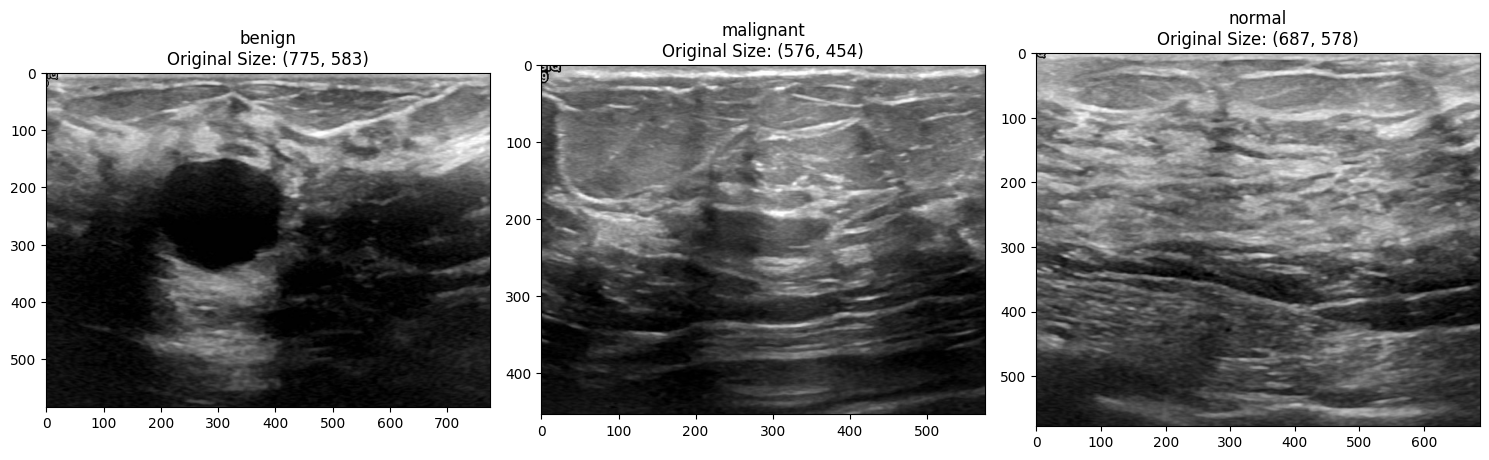

In [4]:
import os
import random
import matplotlib.pyplot as plt
import cv2
from PIL import Image

def show_raw_images(dataset_path, num_images=3):
    classes = ['benign', 'malignant', 'normal']
    plt.figure(figsize=(15, 5))
    for i, cls in enumerate(classes):
        class_folder = os.path.join(dataset_path, 'train', cls)
        if os.path.exists(class_folder) and len(os.listdir(class_folder)) > 0:
            random_img = random.choice(os.listdir(class_folder))
            img_path = os.path.join(class_folder, random_img)
            img = Image.open(img_path)
            plt.subplot(1, 3, i+1)
            plt.imshow(img, cmap='gray')
            plt.title(f"{cls}\nOriginal Size: {img.size}")
            plt.axis('on')
    plt.tight_layout()
    plt.show()

show_raw_images(output_folder)

In [5]:
import numpy as np
import cv2
from PIL import Image
class UltrasoundEnhancement(object):
    def __init__(self, apply_clahe=True, apply_denoise=True):
        self.apply_clahe = apply_clahe
        self.apply_denoise = apply_denoise

    def __call__(self, img):
        img_np = np.array(img.convert('L'))

        if self.apply_denoise:
            img_np = cv2.medianBlur(img_np, 5)

        if self.apply_clahe:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            img_np = clahe.apply(img_np)

        img_rgb = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(img_rgb)

print("UltrasoundEnhancement class created.")

UltrasoundEnhancement class created.


In [6]:
from torch.utils.data import DataLoader
import torch
from torchvision import transforms, datasets
import os
data_transforms = {
    'train': transforms.Compose([
        UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
        transforms.Resize((224, 224)),
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

data_dir = output_folder
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train'), num_workers=2)
               for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Dataset Sizes: {dataset_sizes}")

Classes: ['benign', 'malignant', 'normal']
Dataset Sizes: {'train': 719, 'val': 153, 'test': 158}


In [7]:
def get_model(model_name, num_classes):
    import torch
    import torch.nn as nn
    import timm
    from torchvision import models
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Creating model: {model_name}...")
    # Using timm or torchvision. VGG is standard in torchvision too, but let's stick to timm if installed
    # or just use timm.create_model which supports vgg
    try:
        model = timm.create_model(model_name, pretrained=True)
    except:
        # Fallback to torchvision if timm fails for some reason (unlikely)
        from torchvision import models
        if model_name == 'vgg16': model = models.vgg16(pretrained=True)
    
    # Replace classifier head
    if 'efficientnet' in model_name or 'mobilenet' in model_name:
        if hasattr(model, 'classifier'):
            in_features = model.classifier.in_features
            model.classifier = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(in_features, num_classes)
            )
        elif hasattr(model, 'fc'):
            in_features = model.fc.in_features
            model.fc = nn.Sequential(
                nn.Dropout(0.2),
                nn.Linear(in_features, num_classes)
            )
    elif 'vgg' in model_name:
        # VGG has 'classifier' which is a Sequential. The last layer is usually index 6.
        # We typically replace the last linear layer (4096 -> num_classes)
        # model.classifier[6] = nn.Linear(4096, num_classes)
        # But to be safe and match specs, let's look at the structure.
        if hasattr(model, 'head'): # timm sometimes uses head
             model.head.fc = nn.Linear(model.head.fc.in_features, num_classes)
        elif hasattr(model, 'classifier'):
             # Standard VGG
             in_features = model.classifier[-1].in_features
             model.classifier[-1] = nn.Linear(in_features, num_classes)
    
    return model.to(device)


In [8]:
def train_model(model, criterion, optimizer, num_epochs=20):
    import time
    import copy
    import torch
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

# Training VGG16

In [9]:
import torch.nn as nn
import torch.optim as optim
# VGG16 Setup
print("\n=== Training VGG16 ===")
model_vgg16 = get_model('vgg16', len(class_names))
criterion = nn.CrossEntropyLoss()
optimizer_vgg16 = optim.Adam(model_vgg16.parameters(), lr=1e-4)

# Train VGG16
model_vgg16, history_vgg16 = train_model(model_vgg16, criterion, optimizer_vgg16, num_epochs=20)

# Save VGG16
torch.save(model_vgg16.state_dict(), 'vgg16_ultrasound.pth')
print("Model saved as vgg16_ultrasound.pth")


=== Training VGG16 ===
Creating model: vgg16...
Epoch 1/20
----------
train Loss: 0.9279 Acc: 0.5216
val Loss: 0.8804 Acc: 0.6536

Epoch 2/20
----------
train Loss: 0.7942 Acc: 0.6287
val Loss: 0.6930 Acc: 0.7124

Epoch 3/20
----------
train Loss: 0.7063 Acc: 0.6968
val Loss: 0.7035 Acc: 0.6993

Epoch 4/20
----------
train Loss: 0.5757 Acc: 0.7677
val Loss: 0.5371 Acc: 0.8039

Epoch 5/20
----------
train Loss: 0.5041 Acc: 0.7830
val Loss: 0.5010 Acc: 0.7908

Epoch 6/20
----------
train Loss: 0.4574 Acc: 0.8081
val Loss: 0.6165 Acc: 0.7712

Epoch 7/20
----------
train Loss: 0.3812 Acc: 0.8456
val Loss: 0.4574 Acc: 0.8105

Epoch 8/20
----------
train Loss: 0.4084 Acc: 0.8387
val Loss: 0.4495 Acc: 0.8497

Epoch 9/20
----------
train Loss: 0.3324 Acc: 0.8707
val Loss: 0.4813 Acc: 0.8235

Epoch 10/20
----------
train Loss: 0.3805 Acc: 0.8470
val Loss: 0.4678 Acc: 0.7843

Epoch 11/20
----------
train Loss: 0.3297 Acc: 0.8776
val Loss: 0.6006 Acc: 0.8170

Epoch 12/20
----------
train Loss: 0

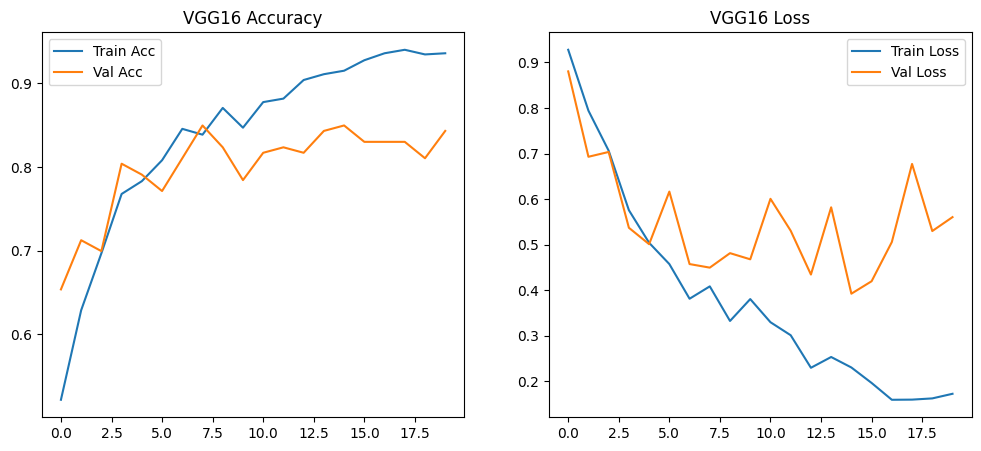

In [10]:
# Plot History for VGG16
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_vgg16['train_acc'], label='Train Acc')
plt.plot(history_vgg16['val_acc'], label='Val Acc')
plt.legend()
plt.title('VGG16 Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history_vgg16['train_loss'], label='Train Loss')
plt.plot(history_vgg16['val_loss'], label='Val Loss')
plt.legend()
plt.title('VGG16 Loss')
plt.show()

In [15]:
def evaluate_model(model, model_name):
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import classification_report, confusion_matrix
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nEvaluating {model_name} on Test Set...")
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in dataloaders['val']: # Assuming 'val' is used for final check or 'test' if available
            # Note: EfficientNet notebook used 'val' in training loop. 
            # If there is a 'test' folder, we should use it. Let's check splits.
            # splitfolders usually gives train/val/test. Let's assume dataloaders['test'] exists if split ratio was 80/10/10
            # EfficientNet notebook used splitfolders.ratio(..., ratio=(.8, .1, .1))
            # So 'test' should exist.
            pass
    
    # Actually let's just write the evaluation loop directly for 'test' set
    test_loader = dataloaders['test'] if 'test' in dataloaders else dataloaders['val']
    
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()


Evaluating VGG16 on Test Set...

Classification Report for VGG16:
              precision    recall  f1-score   support

      benign     0.8370    0.9390    0.8851        82
   malignant     0.9375    0.8182    0.8738        55
      normal     0.8889    0.7619    0.8205        21

    accuracy                         0.8734       158
   macro avg     0.8878    0.8397    0.8598       158
weighted avg     0.8789    0.8734    0.8726       158



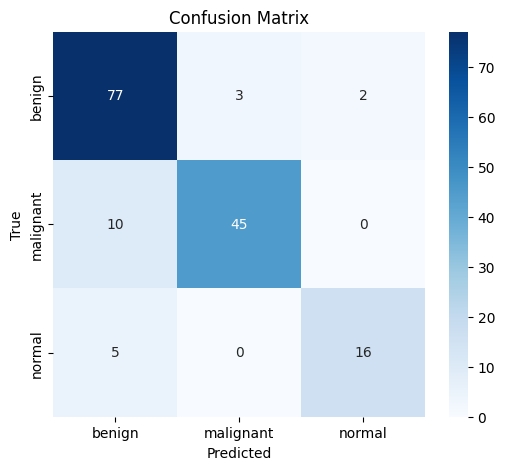

In [16]:
evaluate_model(model_vgg16, "VGG16")


In [25]:
def start_gradcam(model, model_name, target_layer):
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n=== Grad-CAM Visualization: {model_name} ===")
    cam = GradCAM(model=model, target_layers=target_layer)
    
    # Get one image per class from test set
    test_loader = dataloaders['test'] if 'test' in dataloaders else dataloaders['val']
    
    # Quick hack to get 1 per class
    found_classes = []
    
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        for i in range(len(labels)):
            lab = labels[i].item()
            class_name = class_names[lab]
            if class_name not in found_classes:
                found_classes.append(class_name)
                
                input_tensor = inputs[i].unsqueeze(0)
                targets = [ClassifierOutputTarget(lab)]
                
                grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
                
                # Denormalize
                # In EfficientNet notebook, mean/std were not explicitly shown in partial view,
                # but standard imagenet is usually used. Assuming standard normalization.
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                
                img_np = inputs[i].cpu().permute(1, 2, 0).numpy()
                img_rgb = (img_np * std) + mean
                img_rgb = np.clip(img_rgb, 0, 1)
                
                visualization = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)
                
                plt.figure(figsize=(10, 4))
                plt.subplot(1, 2, 1)
                plt.imshow(img_rgb)
                plt.axis('off')
                
                plt.subplot(1, 2, 2)
                plt.imshow(visualization)
                plt.title(f'Grad-CAM - {model_name} ')
                plt.axis('off')
                plt.show()
                
            if len(found_classes) == len(class_names):
                break
        if len(found_classes) == len(class_names):
            break

Processing: ../Dataset/benign/benign (2).png


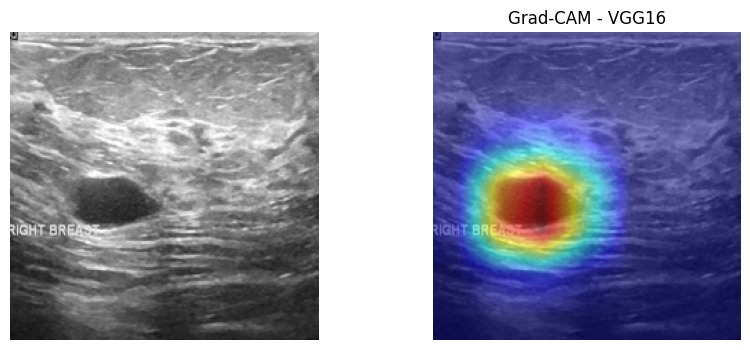

Processing: ../Dataset/malignant/malignant (4).png


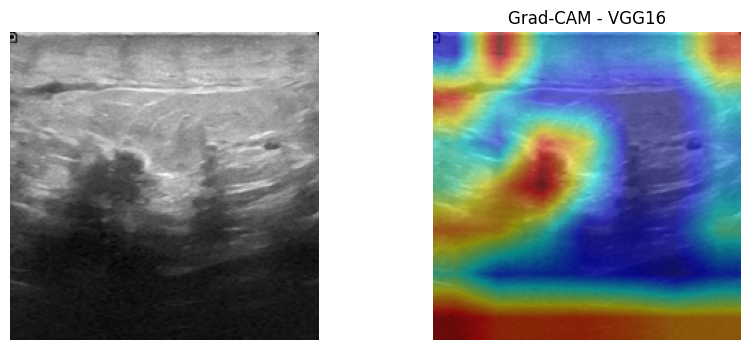

Processing: ../Dataset/normal/normal (4).png


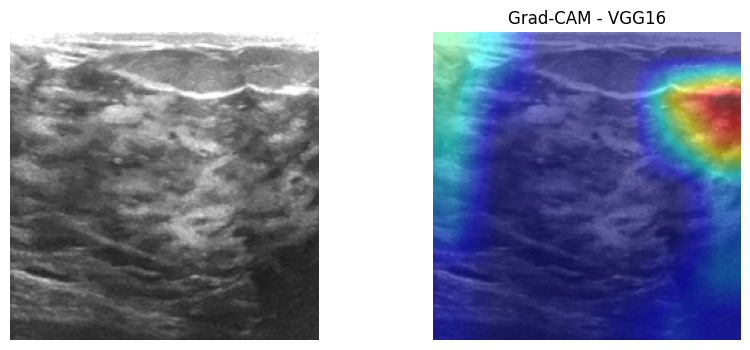

In [27]:
# Grad-CAM Visualization with Manual Paths
import PIL.Image
import cv2
import numpy as np
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import os

# Ensure device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- USER CONFIGURATION ---
test_image_paths = [
    '../Dataset/benign/benign (2).png',
    '../Dataset/malignant/malignant (4).png',
    '../Dataset/normal/normal (4).png'
]
# --------------------------

def start_gradcam_manual(model, model_name, target_layer, image_paths, class_names):
    model.eval()
    model.to(device) # Ensure model is on the correct device
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Initialize GradCAM (removed use_cuda argument which caused TypeError)
    # Device handling is managed by moving the model and input tensor.
    cam = GradCAM(model=model, target_layers=target_layer)
    
    for img_path in image_paths:
        if not os.path.exists(img_path):
            print(f"Image not found: {img_path}")
            continue
            
        print(f"Processing: {img_path}")
        try:
            image = PIL.Image.open(img_path).convert('RGB')
            input_tensor = transform(image).unsqueeze(0).to(device)
            
            grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
            
            # Get prediction
            with torch.no_grad():
                outputs = model(input_tensor)
                probs = torch.nn.functional.softmax(outputs, dim=1)
                confidence, preds = torch.max(probs, 1)
                predicted_class = class_names[preds[0]]
            
            # Visualization
            img_np = np.array(image.resize((224, 224))) / 255.0
            visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
            
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1)
            plt.imshow(img_np)
            plt.axis('off')
            
            plt.subplot(1, 2, 2)
            plt.imshow(visualization)
            plt.axis('off')
            plt.title(f"Grad-CAM - {model_name}")
            plt.show()
            
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            import traceback
            traceback.print_exc()

# Call the function
if 'model_vgg16' in locals():
    target_layer_vgg16 = [model_vgg16.features[-1]]
    if 'class_names' not in locals():
        class_names = ['Benign', 'Malignant', 'Normal'] # Fallback default
    start_gradcam_manual(model_vgg16, "VGG16", target_layer_vgg16, test_image_paths, class_names)